In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("06-study_hours_grades.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 928.0 bytes


In [4]:
X = torch.tensor(df["study_hours"].values, dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df["grade"].values, dtype=torch.float32).unsqueeze(1)

In [5]:
X

tensor([[3.7454],
        [9.5071],
        [7.3199],
        [5.9866],
        [1.5602],
        [1.5599],
        [0.5808],
        [8.6618],
        [6.0111],
        [7.0807],
        [0.2058],
        [9.6991],
        [8.3244],
        [2.1234],
        [1.8182],
        [1.8340],
        [3.0424],
        [5.2476],
        [4.3195],
        [2.9123],
        [6.1185],
        [1.3949],
        [2.9214],
        [3.6636],
        [4.5607],
        [7.8518],
        [1.9967],
        [5.1423],
        [5.9241],
        [0.4645],
        [6.0754],
        [1.7052],
        [0.6505],
        [9.4889],
        [9.6563],
        [8.0840],
        [3.0461],
        [0.9767],
        [6.8423],
        [4.4015],
        [1.2204],
        [4.9518],
        [0.3439],
        [9.0932],
        [2.5878],
        [6.6252],
        [3.1171],
        [5.2007],
        [5.4671],
        [1.8485]])

In [6]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [7]:
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

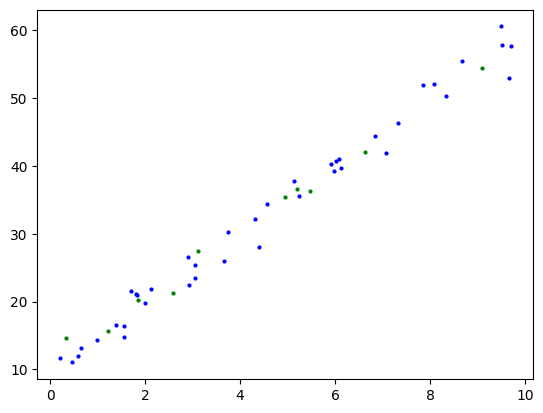

In [8]:
plt.scatter(X_train, y_train, c="b", s=4, label="Training data")
plt.scatter(X_test, y_test, c="g", s=4, label="Testing data")
plt.show()

In [9]:
import torch.nn as nn  

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.linear_layer =nn.Linear(in_features=1, out_features=1)


    def forward(self, x:[torch.Tensor]) -> torch.Tensor:
        return self.linear_layer(x)

In [10]:
torch.manual_seed(42)
model = LinearRegressionModel()

In [11]:
model

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [12]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [13]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.001)

In [14]:
epochs = 120
for epoch in range(epochs):
    model.train()

    y_pred = model(X_train)

    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, y_test)

        if epoch % 5 ==0:
            print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test loss: {test_loss:.5f}")

Epoch: 0 | Loss: 965.63397 | Test loss: 717.68335
Epoch: 5 | Loss: 530.08667 | Test loss: 405.68555
Epoch: 10 | Loss: 295.73618 | Test loss: 236.03226
Epoch: 15 | Loss: 169.61845 | Test loss: 143.42545
Epoch: 20 | Loss: 101.72416 | Test loss: 92.61089
Epoch: 25 | Loss: 65.15111 | Test loss: 64.53108
Epoch: 30 | Loss: 45.42733 | Test loss: 48.86599
Epoch: 35 | Loss: 34.76780 | Test loss: 40.01449
Epoch: 40 | Loss: 28.98463 | Test loss: 34.92719
Epoch: 45 | Loss: 25.82493 | Test loss: 31.93711
Epoch: 50 | Loss: 24.07679 | Test loss: 30.12817
Epoch: 55 | Loss: 23.08825 | Test loss: 28.99337
Epoch: 60 | Loss: 22.50863 | Test loss: 28.24963
Epoch: 65 | Loss: 22.14924 | Test loss: 27.73710
Epoch: 70 | Loss: 21.90859 | Test loss: 27.36426
Epoch: 75 | Loss: 21.73208 | Test loss: 27.07782
Epoch: 80 | Loss: 21.59035 | Test loss: 26.84618
Epoch: 85 | Loss: 21.46758 | Test loss: 26.65017
Epoch: 90 | Loss: 21.35529 | Test loss: 26.47790
Epoch: 95 | Loss: 21.24889 | Test loss: 26.32180
Epoch: 100 | 

In [15]:
X_train.shape

torch.Size([40, 1])

In [16]:
X_train.unsqueeze(1).shape

torch.Size([40, 1, 1])

In [17]:
model.state_dict()

OrderedDict([('linear_layer.weight', tensor([[6.2079]])),
             ('linear_layer.bias', tensor([2.2388]))])

In [20]:
model.eval()
with torch.inference_mode():
    y_preds = model(X_test)

In [21]:
y_preds


tensor([[ 9.8148],
        [32.9787],
        [ 4.3736],
        [58.6882],
        [18.3035],
        [43.3673],
        [21.5894],
        [34.5239],
        [36.1778],
        [13.7143]])

In [22]:
y_test

tensor([[15.6626],
        [35.4731],
        [14.6752],
        [54.4295],
        [21.3220],
        [42.1226],
        [27.4164],
        [36.6609],
        [36.2760],
        [20.2693]])

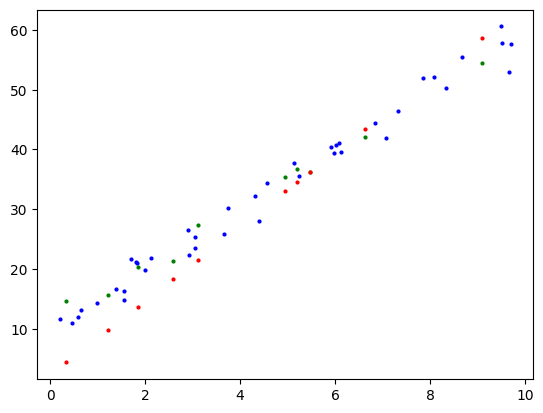

In [23]:
plt.scatter(X_train, y_train, c="b", s=4, label="Training data")
plt.scatter(X_test, y_test, c="g", s=4, label="Testing data")
plt.scatter(X_test, y_preds, c="r", s=4, label="Predictions")
plt.show()